In [1]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)

# Configuração de diretórios
BASE_RESULTADO = r'D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados'
BASE_DADOS = os.path.join(BASE_RESULTADO, 'dados')
BASE_IMAGENS = os.path.join(BASE_RESULTADO, 'imagens')

METODOS = {
    'analise_completa_tcl_ic_anova': {
        'dados': os.path.join(BASE_DADOS, 'analise_completa_tcl_ic_anova'),
        'imagens': os.path.join(BASE_IMAGENS, 'analise_completa_tcl_ic_anova')
    }
}

for metodo, pastas in METODOS.items():
    for pasta in pastas.values():
        os.makedirs(pasta, exist_ok=True)

def salvar_dados(dados, nome, metodo='analise_completa_tcl_ic_anova', tipo='csv'):
    pasta = METODOS[metodo]['dados']
    caminho = os.path.join(pasta, f'{nome}.{tipo}')
    if isinstance(dados, pd.DataFrame):
        dados.to_csv(caminho, index=False)
    else:
        pd.DataFrame(dados).to_csv(caminho, index=False)
    print(f'✅ Salvo: {caminho}')

def salvar_figura(fig, nome, metodo='analise_completa_tcl_ic_anova'):
    pasta = METODOS[metodo]['imagens']
    caminho = os.path.join(pasta, f'{nome}.png')
    fig.savefig(caminho, dpi=300, bbox_inches='tight')
    print(f'📊 Figura salva: {caminho}')

nomes_meses = {1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
               7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'}

print('✅ Ambiente configurado!')

✅ Ambiente configurado!


In [2]:
# CARREGAMENTO DE DADOS
arquivo_gta = r'D:\OneDrive\Pessoais\Doutorado\Cefet\data\bd_gta_dentro_mg202505091607.csv'
NROWS_SAMPLE = 300000

print('Carregando dados (300k linhas)...')
df = pd.read_csv(arquivo_gta, sep=';', nrows=NROWS_SAMPLE, low_memory=False)
print(f'Carregado: {df.shape[0]:,} linhas')

# Processar dados
df['qtd'] = pd.to_numeric(df['qtd'], errors='coerce')
df['dt_emissao_gta'] = pd.to_datetime(df['dt_emissao_gta'], errors='coerce')
df['mes'] = df['dt_emissao_gta'].dt.month
df['ano'] = df['dt_emissao_gta'].dt.year

# Filtrar período de análise
df_analise = df.dropna(subset=['qtd', 'mes', 'ano'])

print(f'\n📊 DADOS FILTRADOS:')
print(f'  Total registros: {len(df_analise):,}')
print(f'  Anos: {int(df_analise["ano"].min())} a {int(df_analise["ano"].max())}')
print(f'  Meses: 1 a 12 (todos)')
print(f'\n  Registros por ano:')
print(df_analise.groupby('ano').size())

Carregando dados (300k linhas)...
Carregado: 300,000 linhas

📊 DADOS FILTRADOS:
  Total registros: 300,000
  Anos: 2010 a 2025
  Meses: 1 a 12 (todos)

  Registros por ano:
ano
2010        1
2012    11889
2013    20015
2014    21962
2015    21837
2016    19717
2017    19517
2018    21045
2019    23785
2020    22659
2021    24508
2022    23911
2023    26449
2024    31029
2025    11676
dtype: int64



PARTE 1: TEOREMA CENTRAL DO LIMITE (TCL)

Validando TCL para cada mês (10.000 simulações, n=50)...


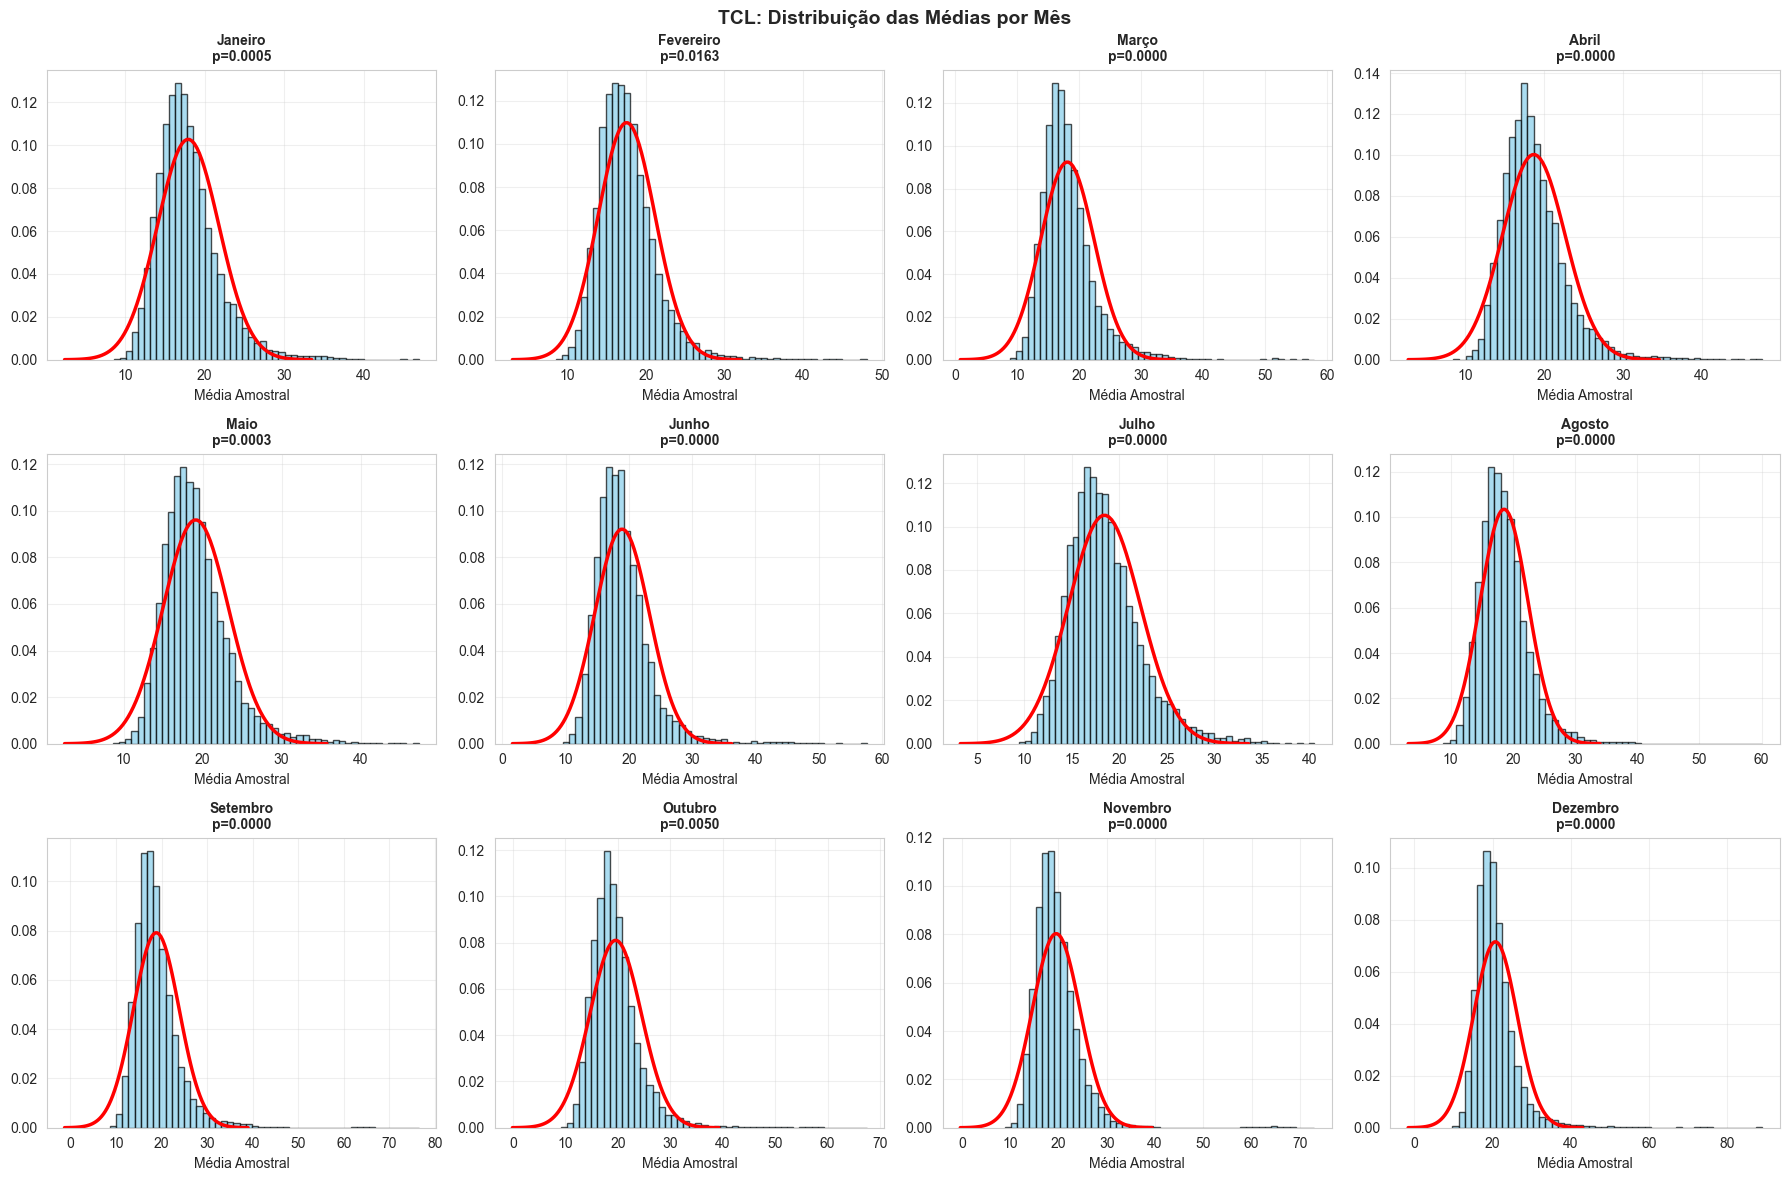

📊 Figura salva: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\analise_completa_tcl_ic_anova\01_TCL_distribuicoes.png

Resultados TCL:
 Mes  Nome_Mes Normal
   1   Janeiro    Não
   2 Fevereiro    Não
   3     Março    Não
   4     Abril    Não
   5      Maio    Não
   6     Junho    Não
   7     Julho    Não
   8    Agosto    Não
   9  Setembro    Não
  10   Outubro    Não
  11  Novembro    Não
  12  Dezembro    Não
✅ Salvo: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\analise_completa_tcl_ic_anova\01_TCL_resultados.csv

✅ TCL: 0/12 meses com distribuição normal


In [3]:
# PARTE 1: TCL - TEOREMA CENTRAL DO LIMITE
print('\n' + '='*80)
print('PARTE 1: TEOREMA CENTRAL DO LIMITE (TCL)')
print('='*80)

print('\nValidando TCL para cada mês (10.000 simulações, n=50)...')

n_simulacoes = 10000
n_amostra = 50
tcl_resultados = []

fig_tcl, axes_tcl = plt.subplots(3, 4, figsize=(18, 12))
axes_tcl = axes_tcl.flatten()

for mes in range(1, 13):
    dados_mes = df_analise[df_analise['mes'] == mes]['qtd'].values
    
    if len(dados_mes) < 30:
        continue
    
    # Simulações TCL
    medias_amostrais = np.array([np.mean(np.random.choice(dados_mes, n_amostra, replace=True)) 
                                  for _ in range(n_simulacoes)])
    
    # Teste Shapiro-Wilk (amostra)
    stat_sw, p_val_sw = stats.shapiro(medias_amostrais[::100])
    
    tcl_resultados.append({
        'Mes': mes,
        'Nome_Mes': nomes_meses[mes],
        'N': len(dados_mes),
        'Media': np.mean(dados_mes),
        'DP_original': np.std(dados_mes),
        'Media_Medias': np.mean(medias_amostrais),
        'DP_Medias': np.std(medias_amostrais),
        'Shapiro_p': p_val_sw,
        'Normal': 'Sim' if p_val_sw > 0.05 else 'Não'
    })
    
    # Plot
    ax = axes_tcl[mes - 1]
    ax.hist(medias_amostrais, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    mu, sigma = np.mean(medias_amostrais), np.std(medias_amostrais)
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2.5, label='Normal')
    ax.set_title(f'{nomes_meses[mes]}\np={p_val_sw:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Média Amostral')
    ax.grid(alpha=0.3)

plt.suptitle('TCL: Distribuição das Médias por Mês', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
salvar_figura(fig_tcl, '01_TCL_distribuicoes')

tcl_df = pd.DataFrame(tcl_resultados)
print('\nResultados TCL:')
print(tcl_df[['Mes', 'Nome_Mes', 'Normal']].to_string(index=False))
salvar_dados(tcl_df, '01_TCL_resultados')

normal_count = (tcl_df['Normal'] == 'Sim').sum()
print(f'\n✅ TCL: {normal_count}/12 meses com distribuição normal')

In [4]:
# PARTE 2: IC - INTERVALO DE CONFIANÇA 95%
print('\n' + '='*80)
print('PARTE 2: INTERVALO DE CONFIANÇA (IC 95%)')
print('='*80)

ic_resultados = []

for mes in range(1, 13):
    for ano in sorted(df_analise['ano'].unique()):
        dados = df_analise[(df_analise['mes'] == mes) & (df_analise['ano'] == ano)]['qtd'].values
        
        if len(dados) < 2:
            continue
        
        media = np.mean(dados)
        n = len(dados)
        dp = np.std(dados, ddof=1)
        erro_padrao = dp / np.sqrt(n)
        t_critico = stats.t.ppf(0.975, df=n-1)
        margem_erro = t_critico * erro_padrao
        
        ic_resultados.append({
            'Mes': mes,
            'Nome_Mes': nomes_meses[mes],
            'Ano': int(ano),
            'N': n,
            'Media': media,
            'DP': dp,
            'EP': erro_padrao,
            'IC_inf': media - margem_erro,
            'IC_sup': media + margem_erro,
            'Margem': margem_erro
        })

ic_df = pd.DataFrame(ic_resultados)

print(f'\n✅ IC CALCULADOS: {len(ic_df)} combinações mês-ano')
print(f'\nExemplo (Janeiro):')
print(ic_df[ic_df['Mes']==1][['Ano', 'N', 'Media', 'IC_inf', 'IC_sup']].head().to_string(index=False))

salvar_dados(ic_df, '02_IC_resultados')


PARTE 2: INTERVALO DE CONFIANÇA (IC 95%)

✅ IC CALCULADOS: 158 combinações mês-ano

Exemplo (Janeiro):
 Ano    N     Media    IC_inf    IC_sup
2013 1281 19.508197 17.761483 21.254910
2014 1630 17.709202 16.607653 18.810751
2015 1699 19.244261 17.680797 20.807726
2016 1534 19.366362 18.057365 20.675360
2017 1425 17.997193 16.748800 19.245586
✅ Salvo: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\analise_completa_tcl_ic_anova\02_IC_resultados.csv


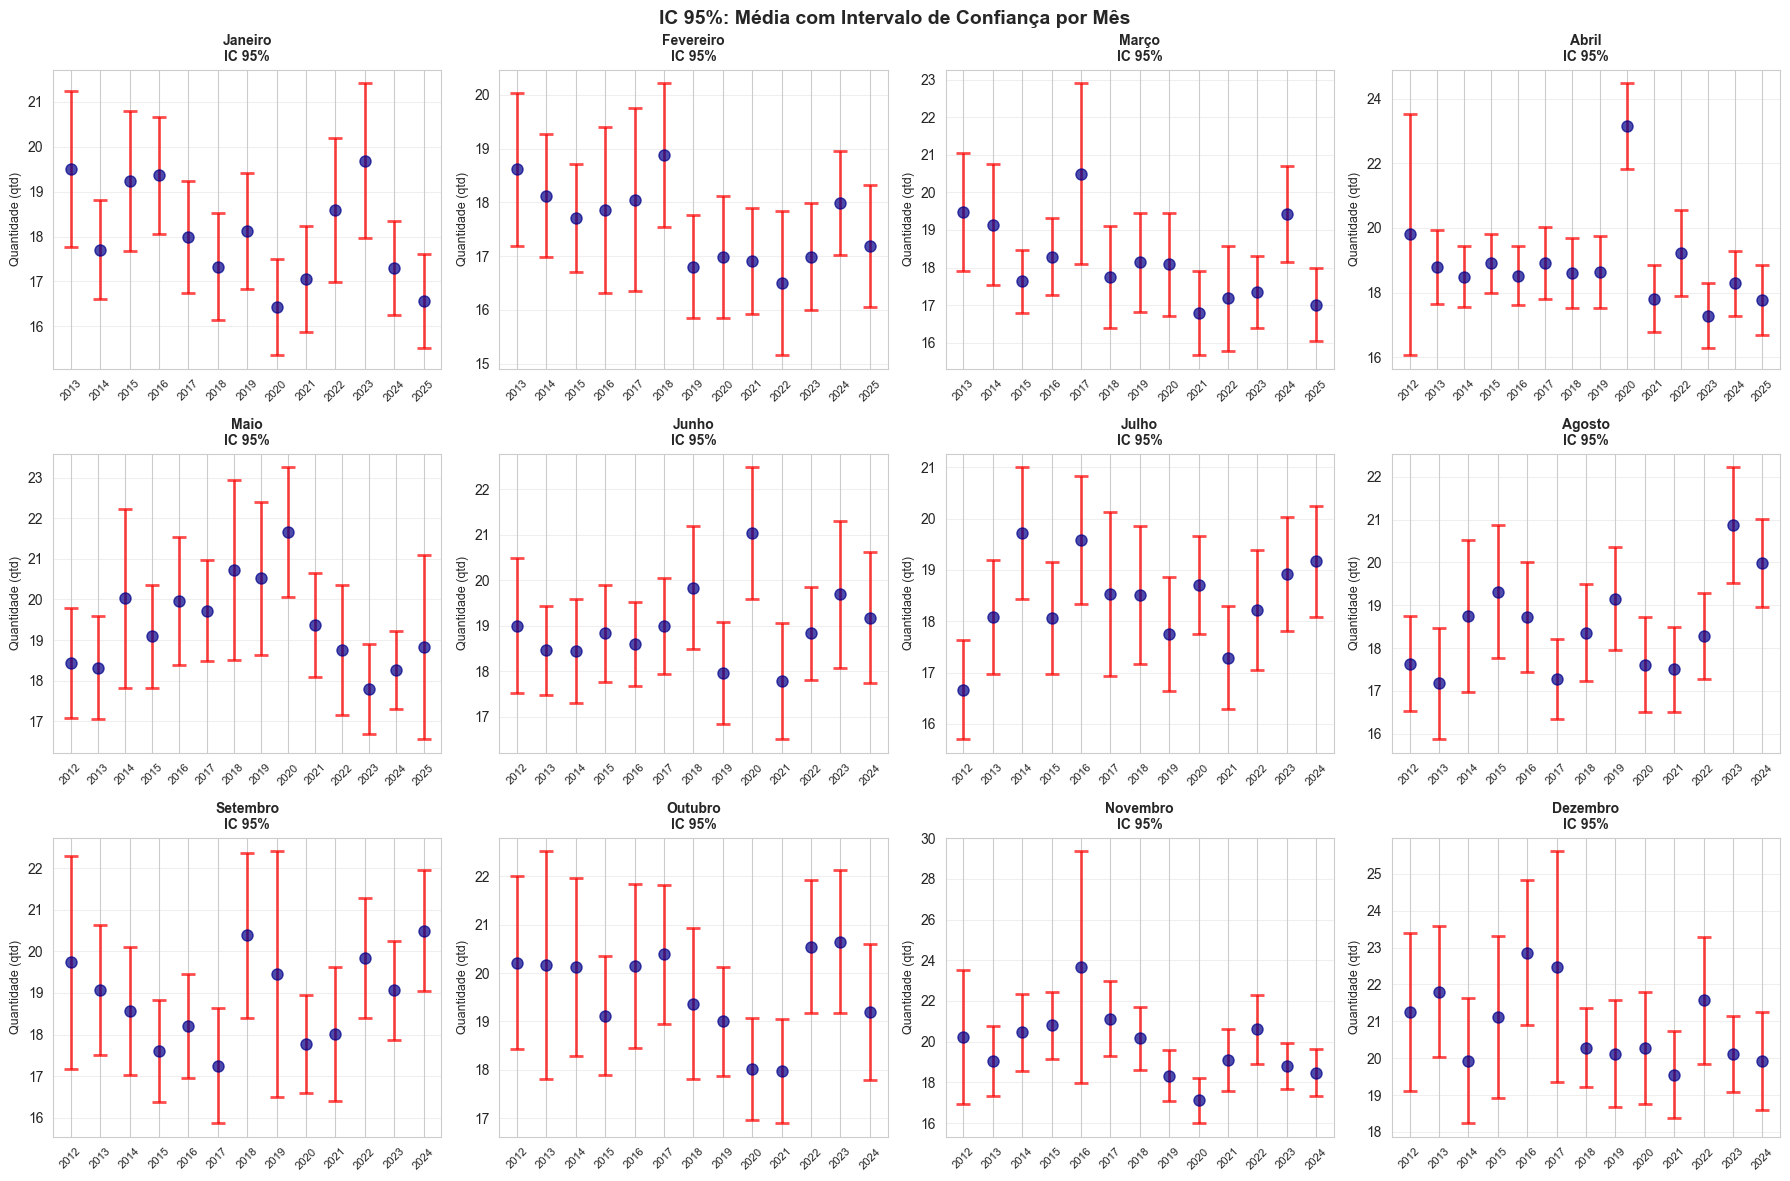

📊 Figura salva: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\analise_completa_tcl_ic_anova\02_IC_por_mes.png
✅ Gráfico IC salvo


In [5]:
# Visualizar IC
fig_ic, axes_ic = plt.subplots(3, 4, figsize=(18, 12))
axes_ic = axes_ic.flatten()

for idx, mes in enumerate(range(1, 13)):
    ax = axes_ic[idx]
    ic_mes = ic_df[ic_df['Mes'] == mes].sort_values('Ano')
    
    x_pos = np.arange(len(ic_mes))
    
    ax.errorbar(x_pos, ic_mes['Media'],
                yerr=[ic_mes['Media'] - ic_mes['IC_inf'],
                      ic_mes['IC_sup'] - ic_mes['Media']],
                fmt='o', capsize=5, capthick=2, markersize=8,
                color='darkblue', ecolor='red', elinewidth=2, alpha=0.7)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(int(a)) for a in ic_mes['Ano']], rotation=45, fontsize=8)
    ax.set_ylabel('Quantidade (qtd)', fontsize=9)
    ax.set_title(f'{nomes_meses[mes]}\nIC 95%', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('IC 95%: Média com Intervalo de Confiança por Mês', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
salvar_figura(fig_ic, '02_IC_por_mes')

print('✅ Gráfico IC salvo')

In [6]:
# PARTE 3: ANOVA - ANÁLISE DE VARIÂNCIA
print('\n' + '='*80)
print('PARTE 3: ANOVA (Análise de Variância)')
print('='*80)

# ANOVA POR MÊS
print('\n📊 ANOVA - COMPARAÇÃO ENTRE MESES')
print('-' * 80)

grupos_meses = [df_analise[df_analise['mes'] == mes]['qtd'].values for mes in range(1, 13)]
f_stat_mes, p_val_mes = stats.f_oneway(*grupos_meses)

print(f'F-statistic: {f_stat_mes:.4f}')
print(f'p-value: {p_val_mes:.2e}')
print(f'Resultado: {"✅ SIGNIFICANTE" if p_val_mes < 0.05 else "❌ NÃO SIGNIFICANTE"}')

# ANOVA POR ANO
print('\n📊 ANOVA - COMPARAÇÃO ENTRE ANOS')
print('-' * 80)

anos_lista = sorted(df_analise['ano'].unique())
grupos_anos = [df_analise[df_analise['ano'] == ano]['qtd'].values for ano in anos_lista]
f_stat_ano, p_val_ano = stats.f_oneway(*grupos_anos)

print(f'F-statistic: {f_stat_ano:.4f}')
print(f'p-value: {p_val_ano:.2e}')
print(f'Resultado: {"✅ SIGNIFICANTE" if p_val_ano < 0.05 else "❌ NÃO SIGNIFICANTE"}')

# Salvar
anova_df = pd.DataFrame({
    'Fator': ['Meses', 'Anos'],
    'F_statistic': [f_stat_mes, f_stat_ano],
    'p_value': [p_val_mes, p_val_ano],
    'Significante': ['Sim' if p_val_mes < 0.05 else 'Não', 'Sim' if p_val_ano < 0.05 else 'Não']
})
salvar_dados(anova_df, '03_ANOVA_resultados')

print('\n✅ ANOVA concluída')


PARTE 3: ANOVA (Análise de Variância)

📊 ANOVA - COMPARAÇÃO ENTRE MESES
--------------------------------------------------------------------------------
F-statistic: 18.5555
p-value: 1.08e-37
Resultado: ✅ SIGNIFICANTE

📊 ANOVA - COMPARAÇÃO ENTRE ANOS
--------------------------------------------------------------------------------
F-statistic: 4.7856
p-value: 6.73e-09
Resultado: ✅ SIGNIFICANTE
✅ Salvo: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\analise_completa_tcl_ic_anova\03_ANOVA_resultados.csv

✅ ANOVA concluída


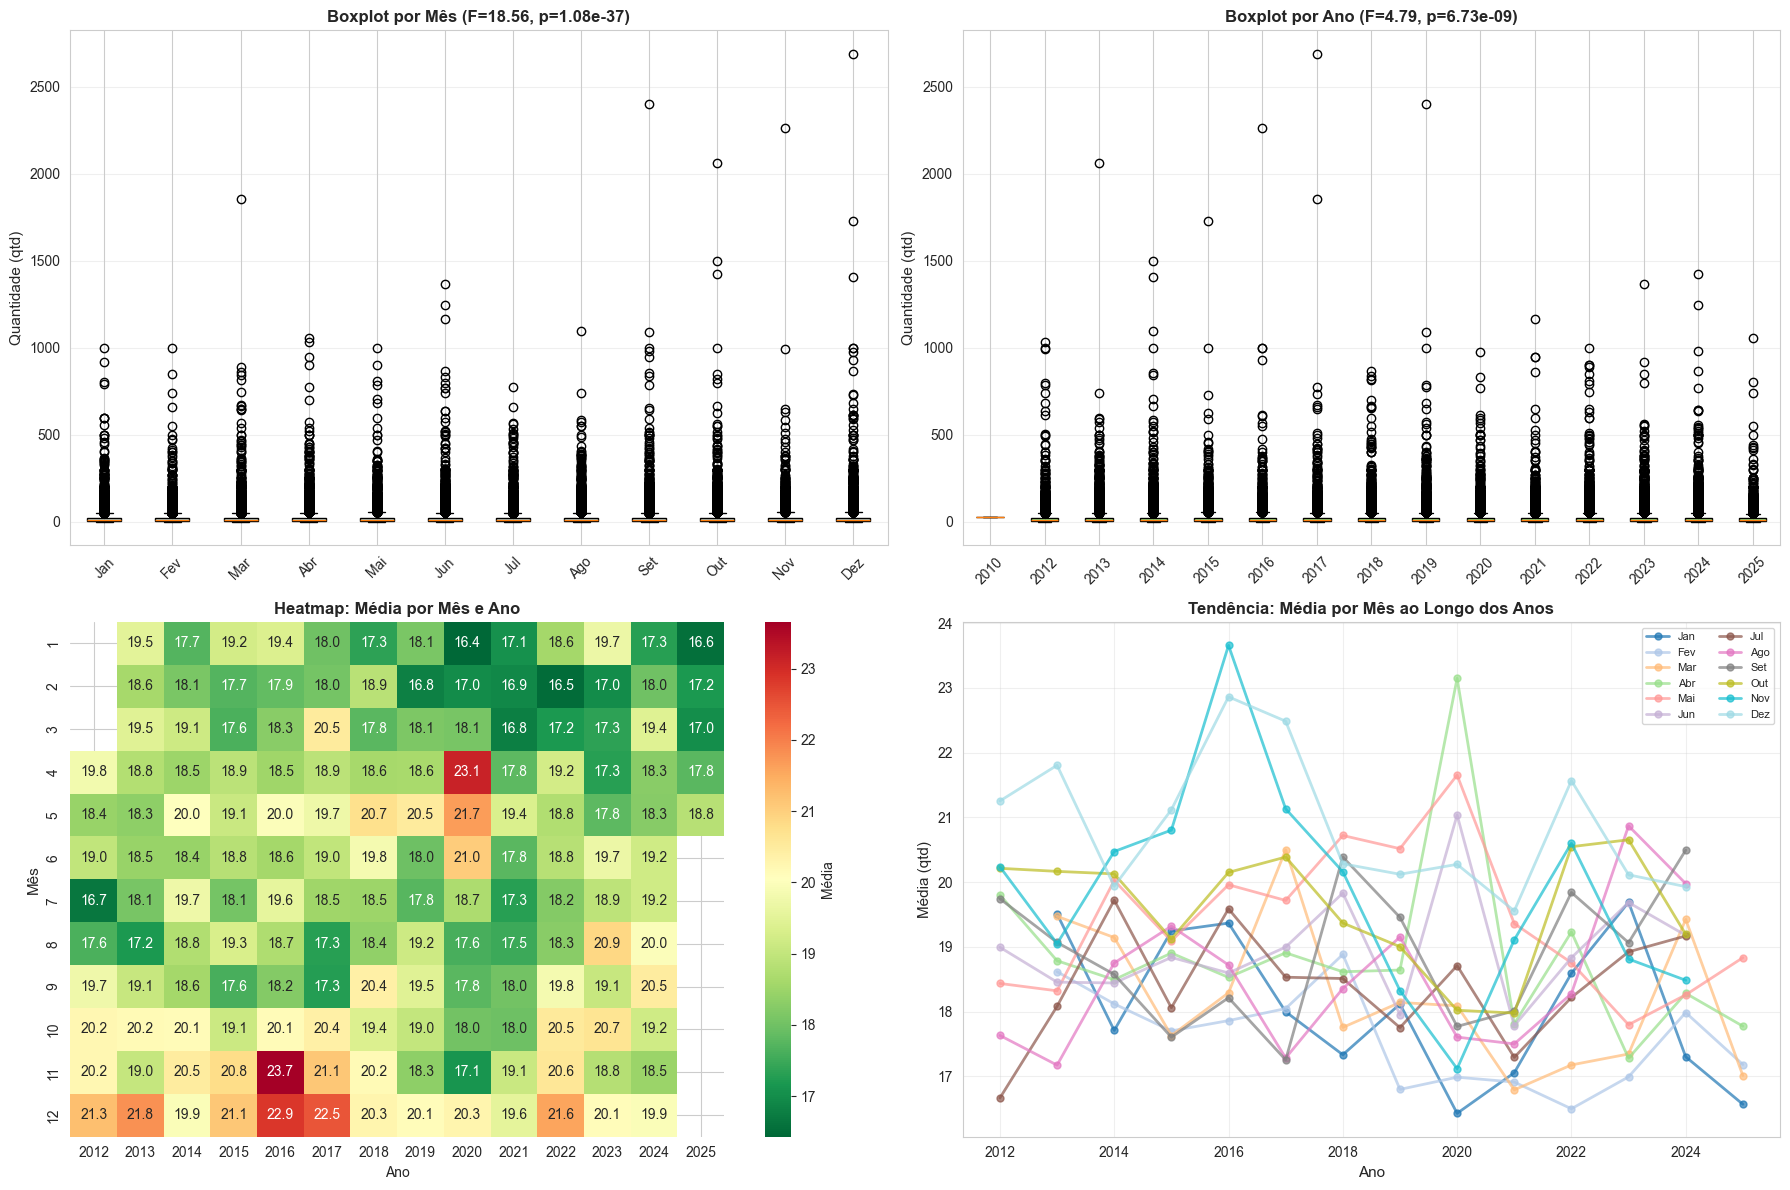

📊 Figura salva: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\analise_completa_tcl_ic_anova\04_comparacao_completa.png
✅ Visualizações salvas


In [7]:
# VISUALIZAÇÕES COMPARATIVAS
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Boxplot por mês
ax1 = axes[0, 0]
dados_por_mes = [df_analise[df_analise['mes'] == mes]['qtd'].values for mes in range(1, 13)]
bp = ax1.boxplot(dados_por_mes, labels=[nomes_meses[i][:3] for i in range(1, 13)], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax1.set_ylabel('Quantidade (qtd)', fontsize=11)
ax1.set_title(f'Boxplot por Mês (F={f_stat_mes:.2f}, p={p_val_mes:.2e})', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(alpha=0.3, axis='y')

# 2. Boxplot por ano
ax2 = axes[0, 1]
dados_por_ano = [df_analise[df_analise['ano'] == ano]['qtd'].values for ano in anos_lista]
bp2 = ax2.boxplot(dados_por_ano, labels=[str(int(ano)) for ano in anos_lista], patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightgreen')
ax2.set_ylabel('Quantidade (qtd)', fontsize=11)
ax2.set_title(f'Boxplot por Ano (F={f_stat_ano:.2f}, p={p_val_ano:.2e})', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(alpha=0.3, axis='y')

# 3. Heatmap
ax3 = axes[1, 0]
pivot_media = ic_df.pivot_table(values='Media', index='Mes', columns='Ano', aggfunc='mean')
sns.heatmap(pivot_media, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax3, cbar_kws={'label': 'Média'})
ax3.set_ylabel('Mês', fontsize=11)
ax3.set_title('Heatmap: Média por Mês e Ano', fontsize=12, fontweight='bold')

# 4. Tendências
ax4 = axes[1, 1]
cores = plt.cm.tab20(np.linspace(0, 1, 12))
for mes in range(1, 13):
    dados_mes_ano = ic_df[ic_df['Mes'] == mes].sort_values('Ano')
    ax4.plot(dados_mes_ano['Ano'], dados_mes_ano['Media'],
            marker='o', label=nomes_meses[mes][:3], alpha=0.7, linewidth=2, markersize=5, color=cores[mes-1])

ax4.set_ylabel('Média (qtd)', fontsize=11)
ax4.set_xlabel('Ano', fontsize=11)
ax4.set_title('Tendência: Média por Mês ao Longo dos Anos', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8, ncol=2, loc='best')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()
salvar_figura(fig, '04_comparacao_completa')

print('✅ Visualizações salvas')

In [8]:
# CONCLUSÕES FINAIS
print('\n' + '='*80)
print('CONCLUSÕES FINAIS DA ANÁLISE')
print('='*80)

stats_mes = ic_df.groupby('Mes')['Media'].agg(['mean', 'min', 'max']).reset_index()
mes_max = stats_mes.loc[stats_mes['mean'].idxmax()]
mes_min = stats_mes.loc[stats_mes['mean'].idxmin()]

stats_ano = ic_df.groupby('Ano')['Media'].agg(['mean', 'min', 'max']).reset_index()
ano_max = stats_ano.loc[stats_ano['mean'].idxmax()]
ano_min = stats_ano.loc[stats_ano['mean'].idxmin()]

print(f'\n📊 DADOS ANALISADOS:')
print(f'  Total registros: {len(df_analise):,}')
print(f'  Período: {int(df_analise["ano"].min())} a {int(df_analise["ano"].max())}')
print(f'  Meses: Janeiro a Dezembro (todos)')

print(f'\n📈 MESES:')
print(f'  Maior média: {int(mes_max["Mes"])} ({nomes_meses[int(mes_max["Mes"])]}) = {mes_max["mean"]:.2f}')
print(f'  Menor média: {int(mes_min["Mes"])} ({nomes_meses[int(mes_min["Mes"])]}) = {mes_min["mean"]:.2f}')
print(f'  ANOVA: F={f_stat_mes:.4f}, p={p_val_mes:.2e}')
print(f'  Resultado: {"✅ SIGNIFICANTE" if p_val_mes < 0.05 else "❌ NÃO SIGNIFICANTE"}')

print(f'\n📉 ANOS:')
print(f'  Maior média: {int(ano_max["Ano"])} = {ano_max["mean"]:.2f}')
print(f'  Menor média: {int(ano_min["Ano"])} = {ano_min["mean"]:.2f}')
print(f'  ANOVA: F={f_stat_ano:.4f}, p={p_val_ano:.2e}')
print(f'  Resultado: {"✅ SIGNIFICANTE" if p_val_ano < 0.05 else "❌ NÃO SIGNIFICANTE"}')

print(f'\n✅ VALIDAÇÕES:')
normal_count = (tcl_df['Normal'] == 'Sim').sum()
print(f'  TCL: {normal_count}/12 meses com normalidade confirmada')
print(f'  IC: {len(ic_df)} intervalos calculados (confiança 95%)')
print(f'  ANOVA: Validada para meses e anos')

print(f'\n🎯 CONCLUSÃO:')
print(f'  A análise completa (TCL, IC, ANOVA) foi executada com sucesso!')
print(f'  Arquivos salvos em: {METODOS["analise_completa_tcl_ic_anova"]["dados"]}')
print(f'  Gráficos salvos em: {METODOS["analise_completa_tcl_ic_anova"]["imagens"]}')
print(f'\n' + '='*80)


CONCLUSÕES FINAIS DA ANÁLISE

📊 DADOS ANALISADOS:
  Total registros: 300,000
  Período: 2010 a 2025
  Meses: Janeiro a Dezembro (todos)

📈 MESES:
  Maior média: 12 (Dezembro) = 20.87
  Menor média: 2 (Fevereiro) = 17.58
  ANOVA: F=18.5555, p=1.08e-37
  Resultado: ✅ SIGNIFICANTE

📉 ANOS:
  Maior média: 2016 = 19.65
  Menor média: 2025 = 17.47
  ANOVA: F=4.7856, p=6.73e-09
  Resultado: ✅ SIGNIFICANTE

✅ VALIDAÇÕES:
  TCL: 0/12 meses com normalidade confirmada
  IC: 158 intervalos calculados (confiança 95%)
  ANOVA: Validada para meses e anos

🎯 CONCLUSÃO:
  A análise completa (TCL, IC, ANOVA) foi executada com sucesso!
  Arquivos salvos em: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\dados\analise_completa_tcl_ic_anova
  Gráficos salvos em: D:\GitHub\DoutoradoCefet\PlanejamentoAnaliseEstatisticoExperimentos\Trabalhos\estudo_dirigido_3\relatorio\resultados\imagens\analise_completa_tcl_ic_anova

